In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [2]:
# i.) Loading the dataset
df = pd.read_csv('spam/email.csv')

# Data Cleaning: Remove potential junk classes (e.g., parsing artifacts with 1 count)
df['Category'] = df['Category'].astype(str).str.strip()
counts = df['Category'].value_counts()
to_keep = counts[counts >= 2].index
df = df[df['Category'].isin(to_keep)]

In [3]:
# ii.) EDA & Feature Engineering
# Create numeric features from text for analysis
df['message_len'] = df['Message'].astype(str).apply(len)
df['word_count'] = df['Message'].astype(str).apply(lambda x: len(x.split()))
df['digit_count'] = df['Message'].astype(str).apply(lambda x: sum(c.isdigit() for c in x))
df['special_char_count'] = df['Message'].astype(str).apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

numeric_features = ['message_len', 'word_count', 'digit_count', 'special_char_count']

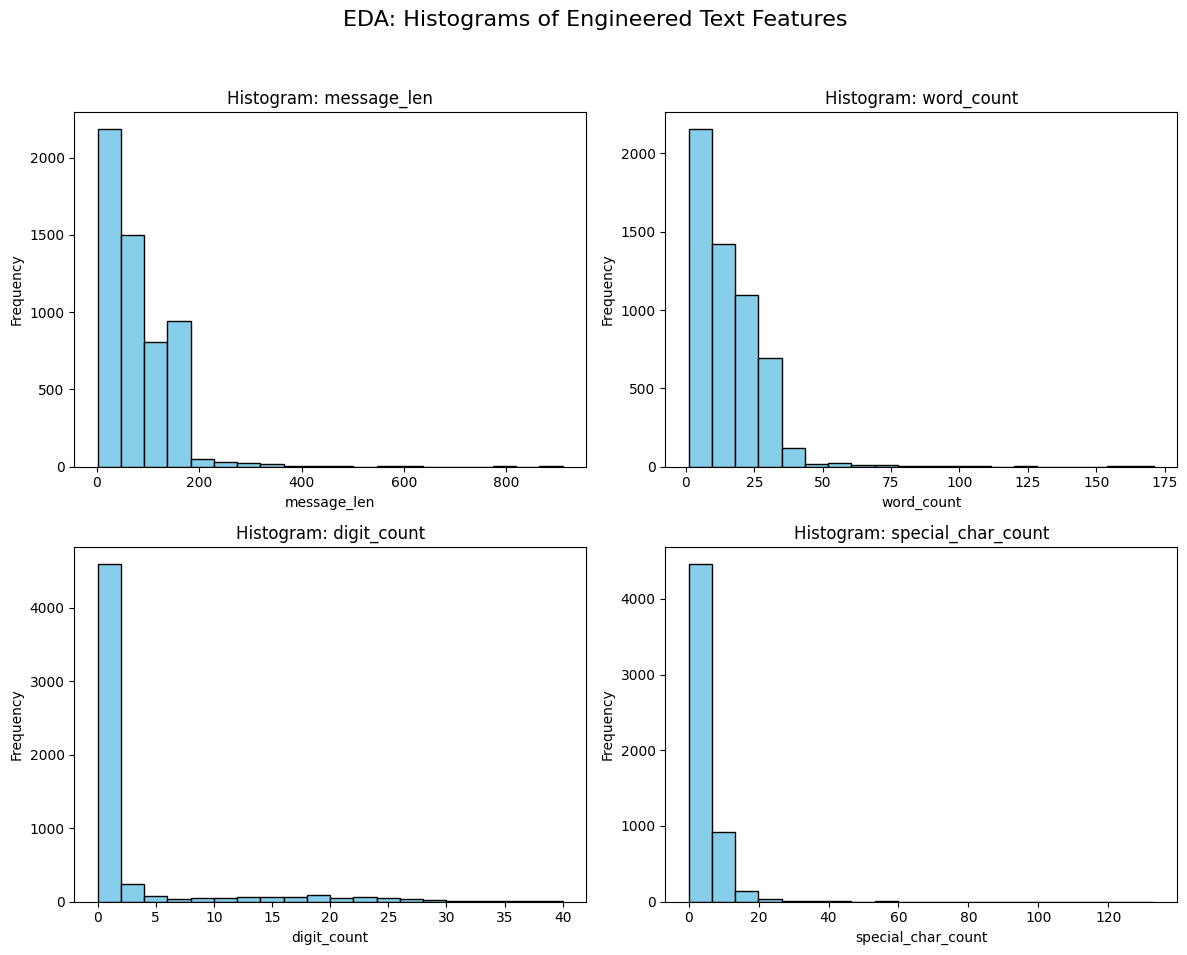

In [4]:
# Grid 1: Histograms (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('EDA: Histograms of Engineered Text Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    ax.hist(df[feature], bins=20, color='skyblue', edgecolor='black', rwidth=1.0)
    ax.set_title(f'Histogram: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('email_histograms.eps', format='eps')
plt.show()

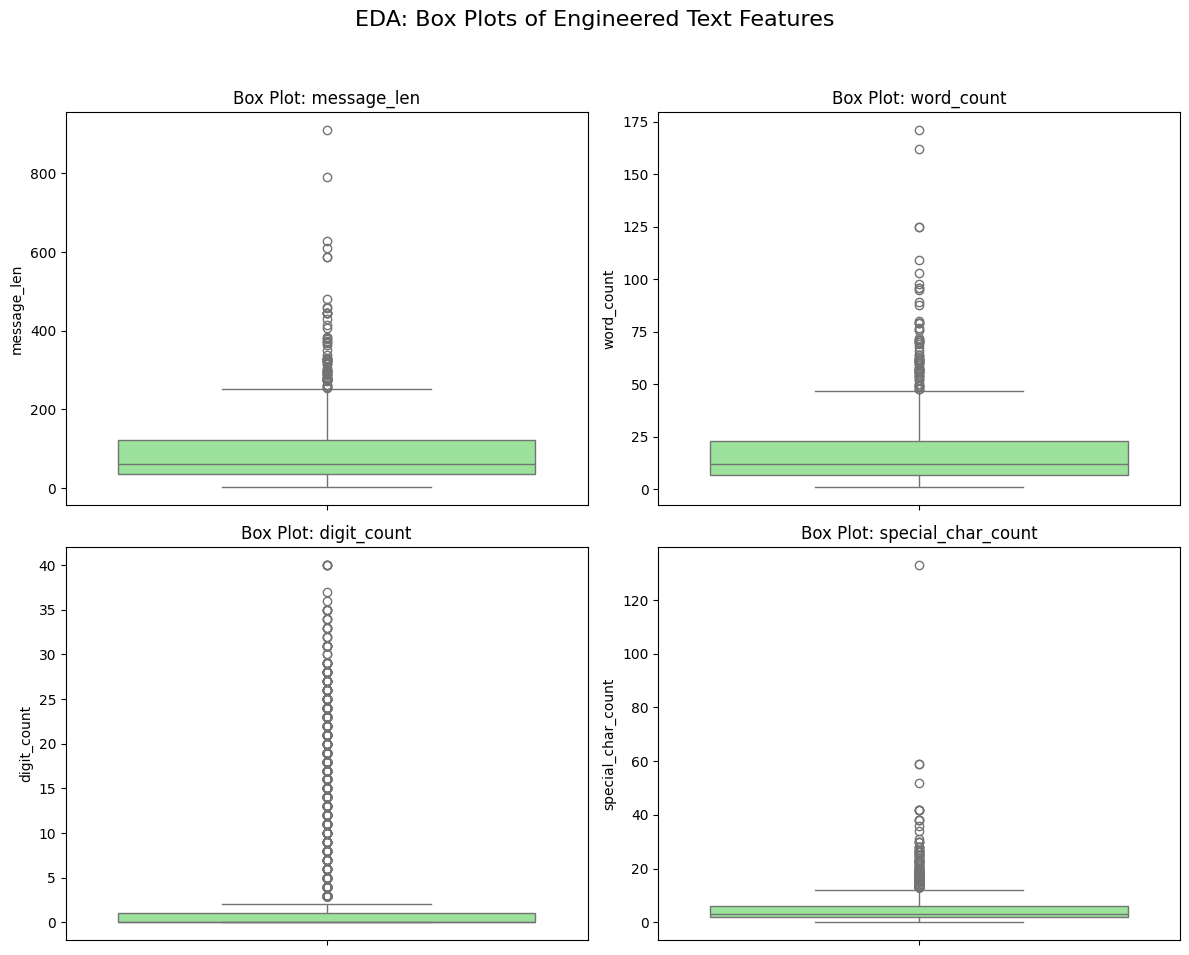

In [5]:
# Grid 2: Box Plots (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('EDA: Box Plots of Engineered Text Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    sns.boxplot(y=df[feature], ax=ax, color='lightgreen')
    ax.set_title(f'Box Plot: {feature}')
    ax.set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('email_boxplots.eps', format='eps')
plt.show()

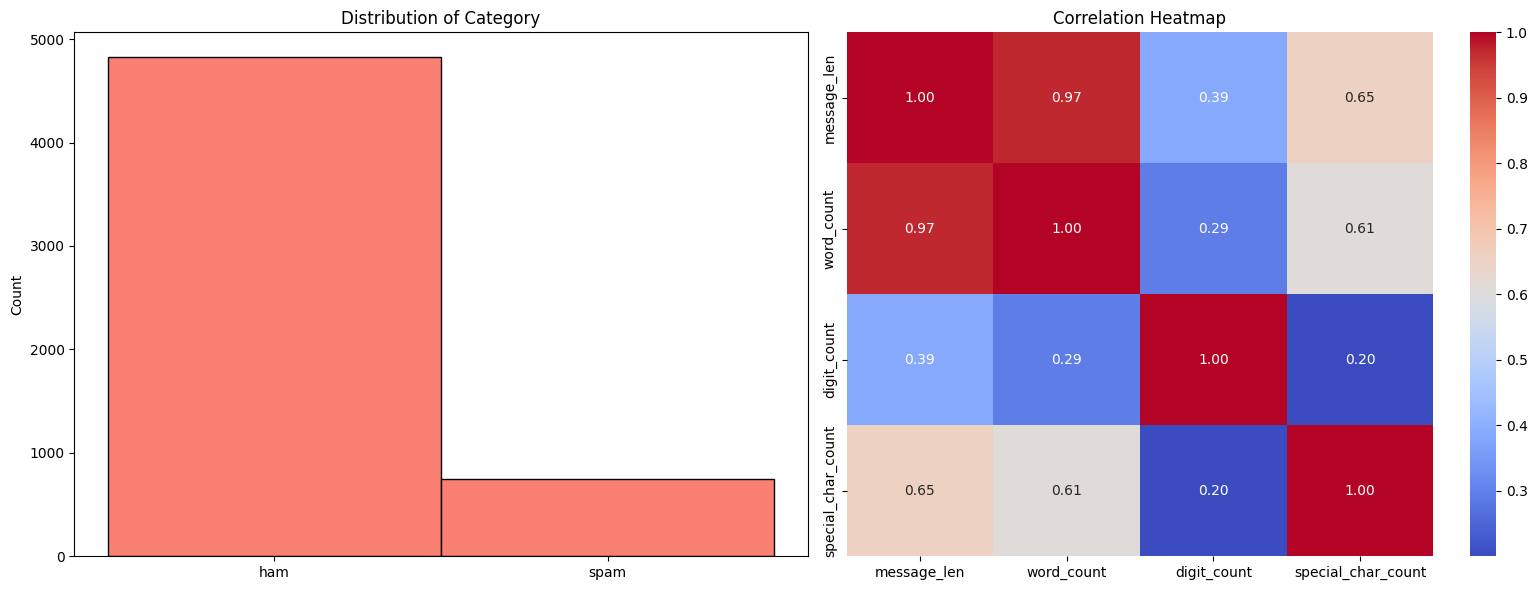

In [6]:
# Grid 3: Categorical Bar Chart & Heatmap (1x2 Grid)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar Chart
counts = df['Category'].value_counts()
axes[0].bar(counts.index, counts.values, width=1.0, color='salmon', edgecolor='black')
axes[0].set_title('Distribution of Category')
axes[0].set_ylabel('Count')

# Heatmap
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('email_cat_heat.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


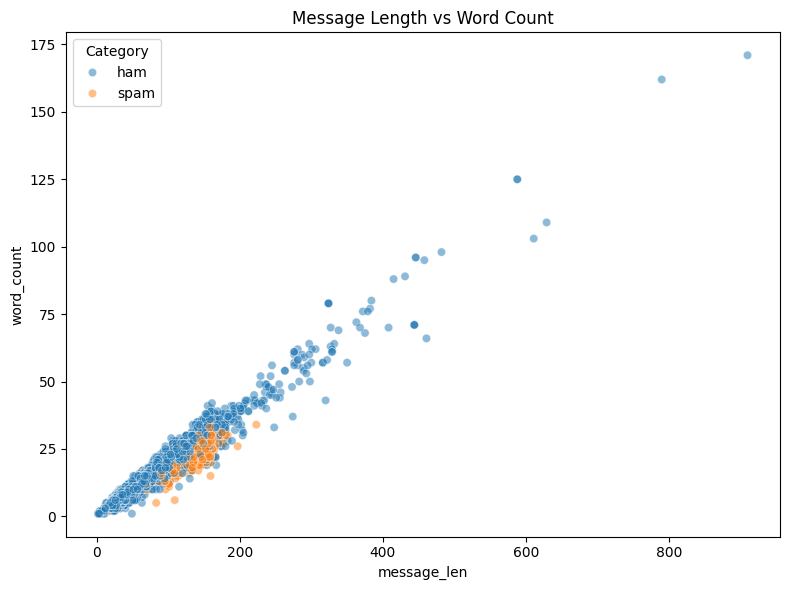

In [7]:
# Grid 4: Scatter Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='message_len', y='word_count', hue='Category', data=df, ax=ax, alpha=0.5)
ax.set_title('Message Length vs Word Count')
plt.tight_layout()
plt.savefig('email_scatter.eps', format='eps')
plt.show()

In [8]:
# iii.) Preprocessing
# Encode Target
le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

X = df[numeric_features]
y = df['Category_Encoded']

# Standardize (for ANOVA, Splitting)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

# MinMax (for Chi-Square)
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

In [9]:
# iv.) Feature Selection

# 1. Chi-Square
print("\n--- Chi-square Test Results ---")
chi2_sel = SelectKBest(chi2, k='all')
chi2_sel.fit(X_minmax_df, y)
chi2_scores = pd.DataFrame({'Feature': X.columns, 'Score': chi2_sel.scores_})
print(chi2_scores.sort_values(by='Score', ascending=False))

# 2. ANOVA
print("\n--- ANOVA Results ---")
anova_sel = SelectKBest(f_classif, k='all')
anova_sel.fit(X_std_df, y)
anova_scores = pd.DataFrame({'Feature': X.columns, 'Score': anova_sel.scores_})
print(anova_scores.sort_values(by='Score', ascending=False))


--- Chi-square Test Results ---
              Feature        Score
2         digit_count  1610.569300
0         message_len    40.249026
1          word_count    23.557862
3  special_char_count     5.360511

--- ANOVA Results ---
              Feature         Score
2         digit_count  13941.444910
0         message_len    930.596036
1          word_count    488.159539
3  special_char_count    143.581017


In [10]:
# v.) Data Splitting
# 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nData Splitting:\nTrain: {X_train.shape}\nVal: {X_val.shape}\nTest: {X_test.shape}")


Data Splitting:
Train: (3900, 4)
Val: (836, 4)
Test: (836, 4)
